In [13]:
import os

from physics.simulation import msq, sample
from physics.hzz import zpair, zz4l
from carl import dataset, model

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
import hist

import torch
from torch.utils.data import DataLoader, TensorDataset
from lightning import Trainer

In [14]:
OUTPUT_DIR = 'run/carl/run-one-test'
SCALER_FILE = 'scaler.pkl'
CHECKPOINT_DIR = 'checkpoints'
SAMPLE_DIR = '..'

checkpoint_epoch = 99
checkpoint_loss = 0.452

CHECKPOINT = f'checkpoint-carl-epoch={checkpoint_epoch}-val_loss={checkpoint_loss}.ckpt'

COMPONENT_1 = msq.Component.SIG
COMPONENT_2 = msq.Component.BKG

SAMPLE_SIZE = 5000
BATCH_SIZE = 32
SEED = 42

In [15]:
xs = {
    msq.Component.SBI : 1.5569109,
    msq.Component.SIG : 0.15105108,
    msq.Component.INT : -0.22043824,
    msq.Component.BKG : 1.6270497
}

filenames = {
    msq.Component.SBI : 'ggZZ2e2m_sbi.csv',
    msq.Component.SIG : 'ggZZ2e2m_sig.csv',
    msq.Component.INT : 'ggZZ2e2m_int.csv',
    msq.Component.BKG : 'ggZZ2e2m_bkg.csv'
}

component_names = {
    msq.Component.SBI : 'SBI',
    msq.Component.SIG : 'SIG',
    msq.Component.INT : 'INT',
    msq.Component.BKG : 'BKG'
}

In [16]:
sample_signal = sample.from_csv(cross_section=xs[COMPONENT_1], file_path=os.path.join(SAMPLE_DIR, filenames[COMPONENT_1]), n_rows=int(SAMPLE_SIZE*1.2))
sample_background = sample.from_csv(cross_section=xs[COMPONENT_2], file_path=os.path.join(SAMPLE_DIR, filenames[COMPONENT_2]), n_rows=int(SAMPLE_SIZE*1.2))
        
z_cand = zpair.ZPairCandidate(algorithm='leastsquare')
z_masses = zpair.ZPairMassWindow(z1=(70,115), z2=(70,115))
angles = zz4l.AngularVariables()
four_lepton_vars = zz4l.FourLeptonSystem()

sample_sig_processed = sample_signal.calculate(z_cand).filter(z_masses).calculate(angles).calculate(four_lepton_vars)[:SAMPLE_SIZE]
sample_bkg_processed = sample_background.calculate(z_cand).filter(z_masses).calculate(angles).calculate(four_lepton_vars)[:SAMPLE_SIZE]

features = ['cth_star', 'cth_1', 'cth_2', 'phi_1', 'phi', 'Z1_mass', 'Z2_mass', '4l_mass', '4l_rapidity']

# Get only required features
X_sig = sample_sig_processed.kinematics[features].to_numpy()
X_bkg = sample_bkg_processed.kinematics[features].to_numpy()

X = torch.cat((torch.tensor(X_sig, dtype=torch.float32), torch.tensor(X_bkg, dtype=torch.float32)))

ratios_sig = (sample_sig_processed.probabilities/sample_sig_processed.reweight(COMPONENT_2, COMPONENT_1).probabilities).to_numpy()
ratios_bkg = (sample_bkg_processed.reweight(COMPONENT_1, COMPONENT_2).probabilities/sample_bkg_processed.probabilities).to_numpy()

ratios = torch.cat((torch.tensor(ratios_sig, dtype=torch.float32), torch.tensor(ratios_bkg, dtype=torch.float32)))

dataset = TensorDataset(X, ratios)

dataloader = DataLoader(dataset, batch_size=BATCH_SIZE)

In [25]:
print(dataset.tensors[0].shape)

torch.Size([10000, 9])


In [17]:
loaded_model = model.CARL.load_from_checkpoint(os.path.join(OUTPUT_DIR, CHECKPOINT_DIR, CHECKPOINT))

In [18]:
trainer = Trainer()
training_predictions = trainer.predict(loaded_model, dataloaders=dataloader)
#validation_predictions = trainer.predict(loaded_model, datamodule=validation_data)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/max/git/ggZZ_work/venv_pytorch/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 313/313 [00:00<00:00, 562.74it/s]


In [26]:
predictions_train = torch.cat(training_predictions).view(-1)
targets_train = ratios/(1+ratios)

In [27]:
print(predictions_train)
print(targets_train)

tensor([1., 1., 1.,  ..., 1., 1., 1.])
tensor([0.9106, 0.8098, 0.5097,  ..., 0.5682, 0.4856, 0.6918])


In [21]:
#predictions_val = torch.cat(validation_predictions).view(-1)
#targets_val = validation_data.prediction_data.get_y().view(-1)

/home/max/git/ggZZ_work/venv_pytorch/lib/python3.10/site-packages/mplhep/utils.py:481: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)


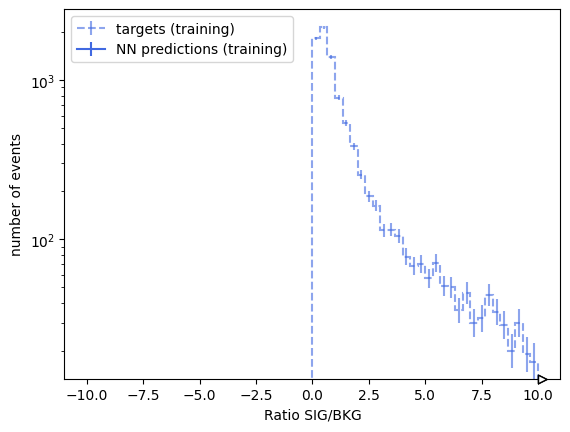

In [ ]:
BINS = 60

bounds = [,10]

h_predictions_train = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_predictions_train.fill(predictions_train/(1-predictions_train))

h_targets_train = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_targets_train.fill(targets_train/(1-targets_train))

#h_predictions_val = hist.Hist(hist.axis.Regular(BINS, *bounds))
#h_predictions_val.fill(predictions_val/(1-predictions_val))

#h_targets_val = hist.Hist(hist.axis.Regular(BINS, *bounds))
#h_targets_val.fill(targets_val/(1-targets_val))


h_targets_train.plot(color='royalblue', linestyle='--', label='targets (training)', alpha=0.6)
h_predictions_train.plot(color='royalblue', linestyle='-', label='NN predictions (training)')


#bin_edges = h_predictions_val.axes[0].edges
#bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
#bin_heights = h_predictions_val.values()

#h_targets_val.plot(color='red', linestyle='--', label='targets (validation)', alpha=0.6)
#plt.scatter(bin_centers, bin_heights, color='red', marker='o', s=20, label='NN predictions (validation)')

plt.xlabel(f'Ratio {component_names[COMPONENT_1]}/{component_names[COMPONENT_2]}')
plt.ylabel('number of events')
plt.yscale('log')

plt.legend()

plt.show()

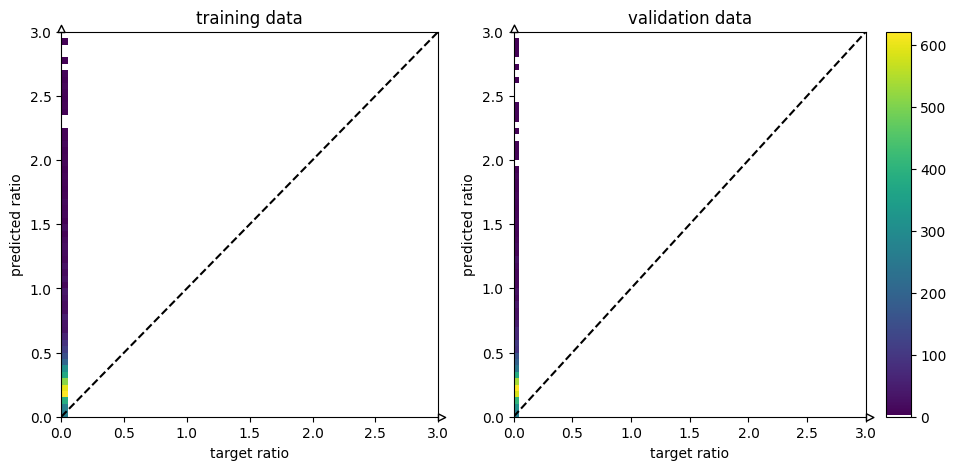

In [ ]:
BINS=60

bounds = [0,3]

h_calibration_train = hist.Hist(
    hist.axis.Regular(BINS, *bounds, name='target ratio'),
    hist.axis.Regular(BINS, *bounds, name='predicted ratio')
)

h_calibration_train.fill(targets_train/(1-targets_train), predictions_train/(1-predictions_train))

h_calibration_val = hist.Hist(
    hist.axis.Regular(BINS, *bounds, name='target ratio'),
    hist.axis.Regular(BINS, *bounds, name='predicted ratio')
)

h_calibration_val.fill(targets_val/(1-targets_val), predictions_val/(1-predictions_val))

cmap = colors.ListedColormap(['white'] + plt.cm.viridis.colors[1:])

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,5))

h_calibration_train.plot2d(ax=ax1, cmap=cmap, cbar=False)
ax1.plot(np.linspace(*bounds), np.linspace(*bounds), color='k', linestyle='--')

ax1.set_title('training data')

h_calibration_val.plot2d(ax=ax2, cmap=cmap)
ax2.plot(np.linspace(*bounds), np.linspace(*bounds), color='k', linestyle='--')

ax2.set_title('validation data')

plt.show()